# 🧠 Model Comparison: With vs Without Cleaning & Feature Engineering

In [1]:

import os
import random
import numpy as np
import pickle
from collections import defaultdict
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from scipy.stats import zscore
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models


In [2]:

# Load LFW Dataset
lfw = fetch_lfw_people(min_faces_per_person=10, resize=0.5, color=True)
images = lfw.images / 255.0
targets = lfw.target
target_names = lfw.target_names

# Create positive and negative pairs
image_groups = defaultdict(list)
for img, label in zip(images, targets):
    image_groups[target_names[label]].append(img)

pairs, labels = [], []
people = list(image_groups.keys())
for person in people:
    imgs = image_groups[person]
    for i in range(len(imgs) - 1):
        pairs.append([imgs[i], imgs[i + 1]])
        labels.append(1)
    for _ in range(len(imgs) - 1):
        neg_person = random.choice([p for p in people if p != person])
        neg_img = random.choice(image_groups[neg_person])
        pairs.append([imgs[0], neg_img])
        labels.append(0)

y = np.array(labels)


In [3]:

def run_basic_models(pairs, y):
    # SVM
    flat = np.array([np.abs(p[0].flatten() - p[1].flatten()) for p in pairs])
    pca = PCA(n_components=128)
    X = pca.fit_transform(flat)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    grid = GridSearchCV(SVC(probability=True), {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}, cv=3)
    grid.fit(X_train, y_train)
    svm_score = grid.score(X_test, y_test)

    # CNN
    arr = np.array(pairs).reshape(-1, 2, 62, 47, 3)
    left, right = arr[:, 0], arr[:, 1]

    def build_branch():
        model = models.Sequential([
            layers.Conv2D(32, (3, 3), activation='relu', input_shape=(62, 47, 3)),
            layers.MaxPooling2D(2, 2),
            layers.Conv2D(64, (3, 3), activation='relu'),
            layers.MaxPooling2D(2, 2),
            layers.Flatten(),
            layers.Dense(128, activation='relu')
        ])
        return model

    l_input, r_input = tf.keras.Input(shape=(62, 47, 3)), tf.keras.Input(shape=(62, 47, 3))
    b_model = build_branch()
    l_encoded, r_encoded = b_model(l_input), b_model(r_input)
    L1 = tf.keras.layers.Lambda(lambda x: tf.abs(x[0] - x[1]))([l_encoded, r_encoded])
    output = tf.keras.layers.Dense(1, activation='sigmoid')(L1)
    cnn_model = tf.keras.Model([l_input, r_input], output)
    cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    Xl_train, Xl_test, Xr_train, Xr_test, y_train_cnn, y_test_cnn = train_test_split(
        left, right, y, test_size=0.2, random_state=42
    )

    cnn_model.fit([Xl_train, Xr_train], y_train_cnn, epochs=5, batch_size=32, validation_split=0.2, verbose=0)
    _, cnn_score = cnn_model.evaluate([Xl_test, Xr_test], y_test_cnn, verbose=0)

    return svm_score, cnn_score


In [4]:

def run_enhanced_models(pairs, y):
    # Clean + Feature Engineering
    flat, features = [], []
    for p1, p2 in pairs:
        diff = np.abs(p1 - p2)
        flat.append(diff.flatten())
        features.append([np.mean(diff), np.std(diff), np.sum(diff)])
    X_flat, X_feat = np.array(flat), np.array(features)

    z_scores = np.abs(zscore(X_flat))
    mask = (z_scores < 3).all(axis=1)
    X_flat, X_feat = X_flat[mask], X_feat[mask]
    y_clean = y[:len(mask)][mask]

    scaler = StandardScaler()
    X_flat_scaled = scaler.fit_transform(X_flat)
    pca = PCA(n_components=128)
    X_pca = pca.fit_transform(X_flat_scaled)
    X_combined = np.hstack([X_pca, X_feat])

    X_train, X_test, y_train, y_test = train_test_split(X_combined, y_clean, test_size=0.2, random_state=42)
    grid = GridSearchCV(SVC(probability=True), {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}, cv=3)
    grid.fit(X_train, y_train)
    svm_score = grid.score(X_test, y_test)
    with open("best_model.pkl", "wb") as f:
        pickle.dump(grid.best_estimator_, f)

    # CNN
    arr = np.array(pairs).reshape(-1, 2, 62, 47, 3)
    left, right = arr[:, 0], arr[:, 1]
    def build_branch():
        model = models.Sequential([
            layers.Conv2D(32, (3, 3), activation='relu', input_shape=(62, 47, 3)),
            layers.MaxPooling2D(2, 2),
            layers.Conv2D(64, (3, 3), activation='relu'),
            layers.MaxPooling2D(2, 2),
            layers.Flatten(),
            layers.Dense(128, activation='relu')
        ])
        return model

    l_input, r_input = tf.keras.Input(shape=(62, 47, 3)), tf.keras.Input(shape=(62, 47, 3))
    b_model = build_branch()
    l_encoded, r_encoded = b_model(l_input), b_model(r_input)
    L1 = tf.keras.layers.Lambda(lambda x: tf.abs(x[0] - x[1]))([l_encoded, r_encoded])
    output = tf.keras.layers.Dense(1, activation='sigmoid')(L1)
    cnn_model = tf.keras.Model([l_input, r_input], output)
    cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    Xl_train, Xl_test, Xr_train, Xr_test, y_train_cnn, y_test_cnn = train_test_split(
        left, right, y, test_size=0.2, random_state=42
    )

    cnn_model.fit([Xl_train, Xr_train], y_train_cnn, epochs=5, batch_size=32, validation_split=0.2, verbose=0)
    _, cnn_score = cnn_model.evaluate([Xl_test, Xr_test], y_test_cnn, verbose=0)

    return svm_score, cnn_score


In [5]:

basic_svm, basic_cnn = run_basic_models(pairs, y)
enhanced_svm, enhanced_cnn = run_enhanced_models(pairs, y)

print("SVM (Basic):", basic_svm)
print("CNN (Basic):", basic_cnn)
print("SVM (Enhanced):", enhanced_svm)
print("CNN (Enhanced):", enhanced_cnn)


c:\Users\91892\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


c:\Users\91892\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor', 'keras_tensor_1']. Received: the structure of inputs=('*', '*')
  warnings.warn(
c:\Users\91892\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\91892\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_16', 'keras_tensor_17']. Received: the structure of inputs=('*', '*')
  warnings.warn(


SVM (Basic): 0.7894421115776845
CNN (Basic): 0.7390521764755249
SVM (Enhanced): 0.8162393162393162
CNN (Enhanced): 0.6982603669166565


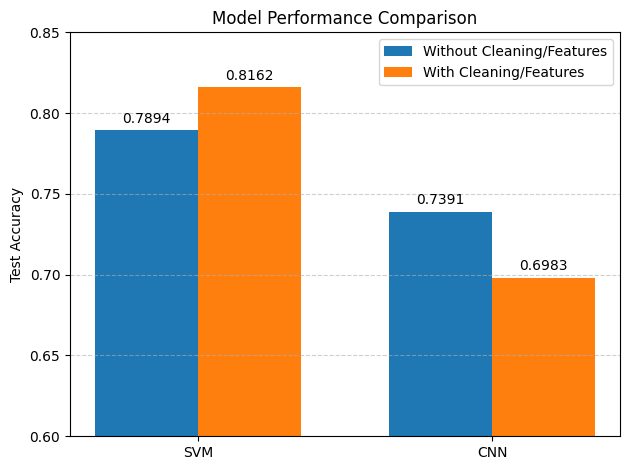

In [6]:

results = {
    "SVM": [basic_svm, enhanced_svm],
    "CNN": [basic_cnn, enhanced_cnn]
}
labels = list(results.keys())
before = [results[k][0] for k in labels]
after = [results[k][1] for k in labels]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots()
b1 = ax.bar(x - width/2, before, width, label='Without Cleaning/Features')
b2 = ax.bar(x + width/2, after, width, label='With Cleaning/Features')

ax.set_ylabel("Test Accuracy")
ax.set_title("Model Performance Comparison")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0.6, 0.85)
ax.legend()
for bars in [b1, b2]:
    for bar in bars:
        ax.annotate(f'{bar.get_height():.4f}', xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
